# UC4 — Evidencia Conversacional: Los usuarios YA piden los 4 UCs

**Objetivo:** Demostrar ante los jueces que UC1–UC4 no son hipotéticos — son intenciones que los usuarios ya expresan en conversaciones reales con Havi.

**Autor:** Diego Quirós | **Proyecto:** datamoles — Datathon DSC x Hey 2026

In [1]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

OUTPUT_DIR = Path('../../outputs/uc4_evidencia_conversacional')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Carga y limpieza

In [2]:
BASE_CONV = Path('/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_dataset_conversaciones 1/dataset_conversaciones')

df = pd.read_parquet(BASE_CONV / 'dataset_50k_anonymized.parquet')
df = df.drop_duplicates()
df['date'] = pd.to_datetime(df['date'], format='mixed')
df['channel_source'] = df['channel_source'].astype(str)

print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print()
print(df.dtypes)
print()
df.head(3)

Shape: (49981, 6)
Columnas: ['input', 'output', 'date', 'conv_id', 'user_id', 'channel_source']

input                        str
output                       str
date              datetime64[ns]
conv_id                      str
user_id                      str
channel_source               str
dtype: object



,input,output,date,conv_id,user_id,channel_source
0,"Me enteré de una promo ""Supercashback Pagos Gu...",Claro que puedo ayudarte! Para participar en l...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
1,La tarjeta de crédito Hey Negocios es diferent...,Claro! La Tarjeta de Crédito Hey Negocios es d...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
2,"Entiendo, gracias",¡De nada! Me alegra haber podido ayudarte. Si ...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1


In [3]:
# Asegurar que input y output sean strings
df['input'] = df['input'].fillna('').astype(str)
df['output'] = df['output'].fillna('').astype(str)

print(f'Mensajes totales:      {len(df):,}')
print(f'Usuarios únicos:       {df["user_id"].nunique():,}')
print(f'Conversaciones únicas: {df["conv_id"].nunique():,}')
print(f'Canal texto (1):       {(df["channel_source"]=="1").sum():,}')
print(f'Canal voz (2):         {(df["channel_source"]=="2").sum():,}')

Mensajes totales:      49,981
Usuarios únicos:       15,025
Conversaciones únicas: 24,119
Canal texto (1):       46,918
Canal voz (2):         3,063


## 2. Clasificación por UC (regex sobre `input`)

In [4]:
keywords = {
    'UC1_rechazos':    r'declinada|rechazada|saldo insuficiente|no pas[oó]|fondos insuficientes|no me dej[oó] pagar',
    'UC2_presupuesto': r'gast[eé]|presupuesto|alcanza|a fin de mes|cu[aá]nto me queda|mis gastos|cu[aá]nto he gastado',
    'UC3_upselling':   r'cashback|hey pro|beneficios|n[oó]mina|rendimiento|cuenta de ahorro|inversi[oó]n|invertir',
    'UC4_fraude':      r'cargo no reconocido|fraude|bloquear|no fui yo|cobro extra[nñ]o|me robaron|desconozco el cargo'
}

masks = {}
for uc, pattern in keywords.items():
    masks[uc] = df['input'].str.contains(pattern, case=False, regex=True, na=False)

# Tabla resumen
total = len(df)
rows = []
for uc, mask in masks.items():
    sub = df[mask]
    rows.append({
        'UC': uc,
        'msgs_match': mask.sum(),
        'pct_total': round(mask.sum() / total * 100, 2),
        'usuarios_unicos': sub['user_id'].nunique(),
        'convs_unicas': sub['conv_id'].nunique()
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# Guardar JSON
summary_df.to_json(OUTPUT_DIR / 'evidencia_uc_summary.json', orient='records', indent=2, force_ascii=False)
print('\n✓ evidencia_uc_summary.json guardado')

             UC  msgs_match  pct_total  usuarios_unicos  convs_unicas
   UC1_rechazos         101       0.20               92            96
UC2_presupuesto          43       0.09               39            41
  UC3_upselling        1238       2.48              767           913
     UC4_fraude         541       1.08              455           510

✓ evidencia_uc_summary.json guardado


## 3. Análisis por channel_source

             UC  texto  voz  pct_texto  pct_voz
   UC1_rechazos     93    8       92.1      7.9
UC2_presupuesto     43    0      100.0      0.0
  UC3_upselling   1179   59       95.2      4.8
     UC4_fraude    528   13       97.6      2.4


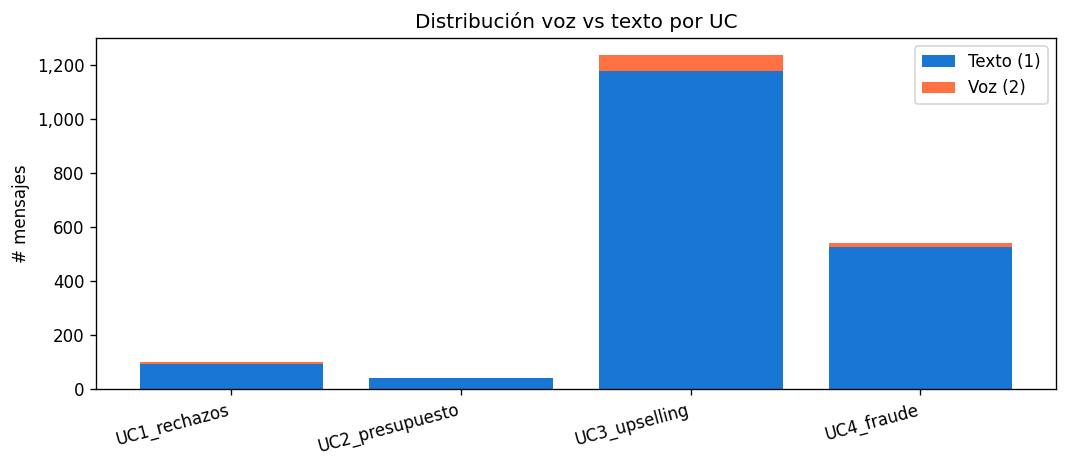

✓ fig_channel_dist.png guardado


In [5]:
channel_rows = []
for uc, mask in masks.items():
    sub = df[mask]
    texto = (sub['channel_source'] == '1').sum()
    voz   = (sub['channel_source'] == '2').sum()
    total_uc = len(sub)
    channel_rows.append({
        'UC': uc,
        'texto': texto,
        'voz': voz,
        'pct_texto': round(texto / total_uc * 100, 1) if total_uc > 0 else 0,
        'pct_voz':   round(voz   / total_uc * 100, 1) if total_uc > 0 else 0,
    })

ch_df = pd.DataFrame(channel_rows)
print(ch_df.to_string(index=False))

# Gráfico barras apiladas
fig, ax = plt.subplots(figsize=(9, 4))
ucs = ch_df['UC']
x = np.arange(len(ucs))
bars_t = ax.bar(x, ch_df['texto'], label='Texto (1)', color='#1976D2')
bars_v = ax.bar(x, ch_df['voz'], bottom=ch_df['texto'], label='Voz (2)', color='#FF7043')
ax.set_xticks(x)
ax.set_xticklabels(ucs, rotation=15, ha='right')
ax.set_ylabel('# mensajes')
ax.set_title('Distribución voz vs texto por UC')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_channel_dist.png', dpi=120)
plt.show()
print('✓ fig_channel_dist.png guardado')

## 4. Ejemplos reales de conversación (3 por UC)

In [6]:
def pick_examples(mask, n=3, seed=42):
    """Elige n ejemplos representativos: inputs más largos (más ricos en info)."""
    sub = df[mask].copy()
    sub['input_len'] = sub['input'].str.split().str.len()
    # top N por longitud de input (más descriptivos)
    return sub.nlargest(n * 5, 'input_len').drop_duplicates('input').head(n)

all_examples = {}
for uc, mask in masks.items():
    examples = pick_examples(mask)
    all_examples[uc] = []
    print(f'\n{'='*60}')
    print(f'  {uc}  ({mask.sum():,} mensajes match)')
    print(f'{'='*60}')
    for _, row in examples.iterrows():
        inp = row['input'][:300]
        out = row['output'][:300]
        print(f'\nUsuario: {inp}')
        print(f'Havi:    {out}')
        all_examples[uc].append({'input': row['input'], 'output': row['output'], 'user_id': str(row['user_id'])})

with open(OUTPUT_DIR / 'evidencia_ejemplos.json', 'w', encoding='utf-8') as f:
    json.dump(all_examples, f, ensure_ascii=False, indent=2)
print('\n✓ evidencia_ejemplos.json guardado')


  UC1_rechazos  (101 mensajes match)

Usuario: Mi tarjeta quedó bloqueada desde el mes de enero por alerta Hey debido a dos compras a la misma empresa por montos diferentes a lo pactado, pero el día de ayer quisieron cobrar otra vez esos montos y fue rechazada por cancelación de la tarjeta
Havi:    Lamento escuchar eso. Es importante que actúes rápidamente. Si tu tarjeta está bloqueada por alertas de compras indebidas, te recomiendo que sigas estos pasos:

1. **Revisa la app Hey**: Ve a la opción de 'Cuentas', selecciona 'Tarjetas' y verifica si puedes desbloquearla desde ahí. 
2. **Reporta el

Usuario: La tramité en la App y la solicitud siempre se queda "En Proceso". Llamé y el ejecutivo comenta que mi solicitud fue rechazada al revisar mi estado en buró de crédito. No tengo ningún problema de score negativo en buró de crédito 
Havi:    Lamento escuchar que tu solicitud está en ese estado. Cuando tramitas tu tarjeta de crédito en la app, si la solicitud está "En Proceso" y te inform

## 5. Análisis de calidad de respuestas de Havi

In [7]:
GENERIC_PHRASES = [
    r'no puedo ayudarte',
    r'comun[ií]cate con soporte',
    r'no tengo acceso',
    r'lo siento',
    r'disculpa',
    r'no cuento con',
    r'no est[aá] disponible',
    r'llama al',
    r'contacta a'
]
generic_pat = '|'.join(GENERIC_PHRASES)

quality_rows = []
for uc, mask in masks.items():
    sub = df[mask].copy()
    if len(sub) == 0:
        continue

    out_words = sub['output'].str.split().str.len()
    inp_words  = sub['input'].str.split().str.len()

    # Respuesta corta a pregunta larga
    short_response = (out_words < 20) & (inp_words >= 10)

    # Respuesta genérica
    generic_response = sub['output'].str.contains(generic_pat, case=False, regex=True, na=False)

    # No menciona ninguna keyword del UC
    offtrack = ~sub['output'].str.contains(keywords[uc], case=False, regex=True, na=False)

    poor = short_response | generic_response | offtrack
    quality_rows.append({
        'UC': uc,
        'total_msgs': len(sub),
        'short_resp': int(short_response.sum()),
        'generic_resp': int(generic_response.sum()),
        'offtrack_resp': int(offtrack.sum()),
        'poor_any': int(poor.sum()),
        'pct_poor': round(poor.sum() / len(sub) * 100, 1)
    })

quality_df = pd.DataFrame(quality_rows)
print(quality_df.to_string(index=False))

             UC  total_msgs  short_resp  generic_resp  offtrack_resp  poor_any  pct_poor
   UC1_rechazos         101           0             6             33        37      36.6
UC2_presupuesto          43           0             1             29        29      67.4
  UC3_upselling        1238           5             4             35        42       3.4
     UC4_fraude         541           0            10             89        96      17.7


## 6. Identificación de gaps

In [8]:
def find_gaps(mask, uc_pattern, n_gaps=10):
    """Inputs frecuentes que reciben respuestas genéricas o fuera de tema."""
    sub = df[mask].copy()
    generic_mask = sub['output'].str.contains(generic_pat, case=False, regex=True, na=False)
    offtrack_mask = ~sub['output'].str.contains(uc_pattern, case=False, regex=True, na=False)
    poor_mask = generic_mask | offtrack_mask
    
    poor_inputs = sub[poor_mask]['input'].str.lower().str.strip()
    counts = Counter(poor_inputs)
    top = counts.most_common(n_gaps)
    
    gaps = []
    for inp_text, freq in top:
        # Busca un output de ejemplo
        sample_out = sub[sub['input'].str.lower().str.strip() == inp_text]['output'].iloc[0] if freq > 0 else ''
        gaps.append({'input': inp_text, 'freq': freq, 'sample_output': sample_out[:200]})
    return gaps

all_gaps = {}
for uc, mask in masks.items():
    gaps = find_gaps(mask, keywords[uc])
    all_gaps[uc] = gaps
    print(f'\n--- {uc} — Top 2 gaps ---')
    for g in gaps[:2]:
        print(f'  Input ({g["freq"]}x): {g["input"][:120]}')
        print(f'  Output: {g["sample_output"][:120]}')

with open(OUTPUT_DIR / 'evidencia_gaps.json', 'w', encoding='utf-8') as f:
    json.dump(all_gaps, f, ensure_ascii=False, indent=2)
print('\n✓ evidencia_gaps.json guardado')


--- UC1_rechazos — Top 2 gaps ---
  Input (2x): compra rechazada
  Output: Lamento escuchar eso. Si te están rechazando la transacción en línea, asegúrate de estar usando la tarjeta virtual. Tamb
  Input (1x): mas  abisinecesito  ayuda  con  una  tran  una  transaccion  que  estoy  haciendo  en  facebook  de  mi  tarjeta  de  et
  Output:  Disculpa  por  el  inconveniente . Si  no  puedes  realizar  el  pago  con  tu  tarjeta  de  débito  en  Facebook ,  es

--- UC2_presupuesto — Top 2 gaps ---
  Input (1x): en cuanto me quedarían mis mensualidades
  Output: Claro! Para un crédito automotriz de $274,000 pesos a 60 meses, con un enganche de $170,000 pesos, la mensualidad que te
  Input (1x): ok entonces si no gaste nada antes del.17 de marzo y hoy 18 de marzo la uso lo pago cuando? porque me dice fecha de cort
  Output: Si tu fecha de corte es el 25 de febrero y hoy, 18 de marzo, usas tu tarjeta, deberás pagar el monto que gastaste en tu 

--- UC3_upselling — Top 2 gaps ---
  Input (1x

## 7. Visualizaciones

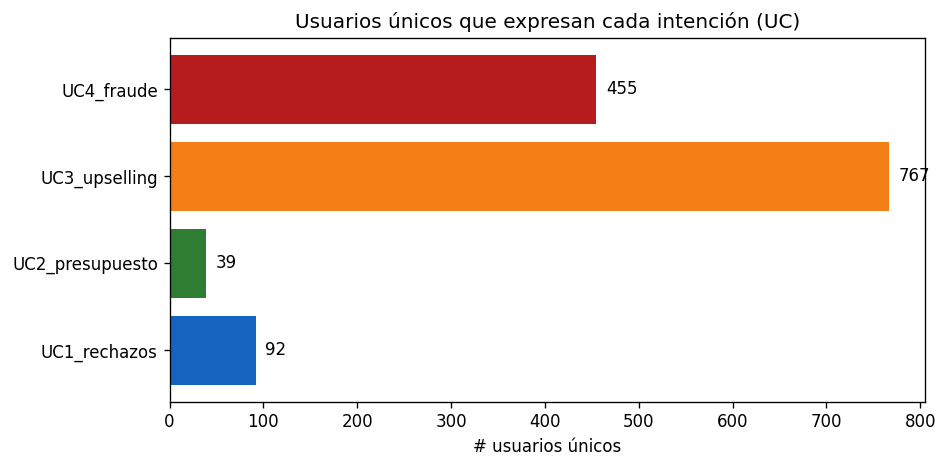

✓ fig_usuarios_por_uc.png guardado


In [9]:
# Gráfico 1: usuarios únicos por UC
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1565C0', '#2E7D32', '#F57F17', '#B71C1C']
ucs = summary_df['UC']
usuarios = summary_df['usuarios_unicos']
bars = ax.barh(ucs, usuarios, color=colors)
ax.set_xlabel('# usuarios únicos')
ax.set_title('Usuarios únicos que expresan cada intención (UC)')
for bar, val in zip(bars, usuarios):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_usuarios_por_uc.png', dpi=120)
plt.show()
print('✓ fig_usuarios_por_uc.png guardado')

In [10]:
# Resumen final en consola
print('\n' + '='*65)
print('  RESUMEN FINAL — Evidencia conversacional por UC')
print('='*65)
print(summary_df.to_string(index=False))
print()
print('Archivos guardados en:', OUTPUT_DIR.resolve())
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  - {f.name}')


  RESUMEN FINAL — Evidencia conversacional por UC
             UC  msgs_match  pct_total  usuarios_unicos  convs_unicas
   UC1_rechazos         101       0.20               92            96
UC2_presupuesto          43       0.09               39            41
  UC3_upselling        1238       2.48              767           913
     UC4_fraude         541       1.08              455           510

Archivos guardados en: /Users/diegodq/Documents/dev/datamoles/Datathon-2026/outputs/uc4_evidencia_conversacional
  - evidencia_ejemplos.json
  - evidencia_gaps.json
  - evidencia_uc_summary.json
  - fig_channel_dist.png
  - fig_usuarios_por_uc.png
